# Snow Depth Estimates with ICESat-2

This notebook uses a combination of ICESat-2 and airborne lidar to derive snow depth. It uses data from the SnowEx 2023 campaign as an example, but can be applied to other locations if a shapefile or geoJSON is given.

This notebook is adapted from the 2023 ICESat-2 Hackweek, originally developed by Zachary Fair and Karina Zikan.

## User input

Acceptable field site IDs over Alaska are:
* `cffl`: Creamer's Field/Farmer's Loop
* `cpcrw`: Caribou/Poker Creek Experimental Watershed
* `bcef`: Bonanza Creek Experimental Forest
* `acp`: Arctic Coastal Plain
* `utk`: Toolik Research Station

Acceptable IDs for Sliderule ATL08 class (use numeric ID):
* `No classification:` -1
* `atl08_unclassified`: 0
* `atl08_noise`: 1
* `atl08_canopy`: 2
* `atl08_top_of_canopy`: 3
* `atl08_ground`: 4

In [21]:
# Field site ID
field_id = '/home/jovyan/shared-public/SnowPit/snow-depth/toolik_lidar_boxes.geojson'

# Snow-on (True) or snow-off (False) analysis
snow_on = True

# Use March UAF data ('mar') or October depths ('oct')
uaf_depths = 'mar'

# Base data path
path = '/home/jovyan/icesat2-snowex'

# Desired RGT and date range for data queries. Set rgt to "all" if
# all ground tracks are desired
date_range = ['2023-03-01', '2023-04-01']
rgt = '152'

# SlideRule parameters (optional)
cnf_surface = 4
atl08_class = 4
segment_length = 40
res = 20

A breakdown of the SlideRule parameters above:

`cnf_surface`: The confidence level of the ICESat-2 photons.
* High-confidence photons (recommended for snow): 4
* High-/medium-confidence photons: 3
* High-/medium-/low-confidence photons: 2
* Signal photons (high/medium/low) and noise: 1
* Signal photons, noise, and solar background (not recommended): 0

`segment_length`: The along-track length to sample and aggregate photons, in meters. Currently set at 40 m, the resolution of the ATL06 product.

`res`: The along-track resolution of the returned data product. Currently set at 20 m to match ATL06.

## Read ICESat-2 data
To load the ICESat-2 data with minimal effort from the user, we will use SlideRule in the below function.

In [22]:
from sliderule import sliderule, icesat2

def atl06srq(field_geojson, date_range, rgt, cnf_surface, atl08_class, 
             segment_length, res, dem_query="None"):
    # Initiate SlideRule
    icesat2.init('slideruleearth.io', verbose=False)

    # Load geoJSON for site of interest
    region = sliderule.toregion(field_geojson)['poly']

    # Convert user-defined ATL08 class ID to string readable by SlideRule
    atl08_ids = {-1: 'None',
                 0: 'atl08_unclassified',
                 1: 'atl08_noise',
                 2: 'atl08_canopy',
                 3: 'atl08_top_of_canopy',
                 4: 'atl08_ground'}

    # Construct dictionary of parameters
    time_root = 'T00:00:00Z'
    parms = {
             "poly": region,
             "srt": icesat2.SRT_LAND,
             "cnf": cnf_surface,
             "len": segment_length,
             "res": res,
             "t0": date_range[0]+time_root,
             "t1": date_range[1]+time_root
            }

    # Check if all RGTs are considered, or only a subset
    if rgt != "all":
        parms["rgt"] = rgt
        print(f"Subsetting to only include ICESat-2 RGT {rgt}.")

    # Check for ATL08 filter
    if atl08_ids.get(atl08_class) != "None":
        parms["atl08_class"] = atl08_ids.get(atl08_class)
        print("Subsetting by selected ATL08 filter...")

    # Check for DEM request
    if dem_query != "None":
        parms["samples"] = {"mosaic": {"asset": dem_query, "radius": 10.0, "zonal_stats": True}}
        print(f"Adding DEM/raster: {dem_query}")

    # Query SlideRule
    atl06sr = icesat2.atl06p(parms)

    return atl06sr

In [23]:
# Generate ICESat-2 data from SlideRule
atl06sr = atl06srq(field_id, date_range, rgt,
                 cnf_surface=cnf_surface,
                 atl08_class=atl08_class,
                 segment_length=segment_length,
                 res=res)

Subsetting to only include ICESat-2 RGT 152.
Subsetting by selected ATL08 filter...


In [24]:
# Convert ATL06SR to geodataframe in EPSG:32606
atl06sr['lon'], atl06sr['lat'] = atl06sr.geometry.x, atl06sr.geometry.y
atl06sr_gdf = atl06sr.to_crs('epsg:32606')

In [25]:
atl06sr_gdf

,gt,pflags,w_surface_window_final,region,dh_fit_dx,n_fit_photons,h_mean,h_sigma,cycle,rgt,y_atc,rms_misfit,x_atc,spot,segment_id,geometry,lon,lat
time,,,,,,,,,,,,,,,,,,
2023-03-31 08:03:54.177860096,10,0,3.00000,5,0.021294,256,861.359161,0.009344,19,152,-20941.541016,0.149369,12417928.0,1,619958,POINT (404240.266 7616607.946),-149.356901,68.644949
2023-03-31 08:03:54.180682496,10,0,3.00000,5,0.015136,263,861.719451,0.009936,19,152,-20941.390625,0.160900,12417948.0,1,619959,POINT (404237.44 7616588.16),-149.356952,68.644771
2023-03-31 08:03:54.183505920,10,0,3.00000,5,0.012720,246,861.994732,0.012270,19,152,-20941.244141,0.192446,12417968.0,1,619960,POINT (404234.607 7616568.361),-149.357003,68.644592
2023-03-31 08:03:54.186328576,10,0,3.00000,5,0.013357,267,862.272052,0.012559,19,152,-20941.103516,0.204960,12417988.0,1,619961,POINT (404231.769 7616548.562),-149.357054,68.644414
2023-03-31 08:03:54.189144320,10,0,3.00000,5,0.011575,265,862.544557,0.013301,19,152,-20940.976562,0.215835,12418008.0,1,619962,POINT (404228.918 7616528.765),-149.357105,68.644235
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-03-31 08:03:57.087859968,40,0,3.00000,5,0.020959,21,807.455541,0.044278,19,152,-24281.343750,0.197318,12436221.0,4,620872,POINT (398214.823 7599029.414),-149.487556,68.485307
2023-03-31 08:03:57.089837056,20,0,13.11412,5,-0.513720,10,1045.074338,0.335222,19,152,-20995.527344,1.046813,12436121.0,2,620867,POINT (401477.898 7598638.316),-149.407525,68.482965
2023-03-31 08:03:57.090686976,40,0,3.00000,5,0.002173,20,807.625993,0.055433,19,152,-24281.173828,0.246033,12436241.0,4,620873,POINT (398212.008 7599009.613),-149.487605,68.485128


## Read Airborne Lidar Data

To derive snow depth with ICESat-2, we need a snow-off digital elevation model (DEM), which commonly originates from airborne lidar. This next step is designed to load and prepare some airborne lidar data from the University of Alaska, Fairbanks for this analysis.

In [26]:
import rioxarray as rio

# Snow-off lidar DEM
f_snow_off = f'{path}/lidar-dems/UKT_2023sept16_dtm_3m.tif'

# Snow-on lidar DEM (for comparison with the ICESat-2 results)
f_snow_on = f'{path}/lidar-dems/UKT_2023mar13_snowdepth_3m.tif'

# Read lidar DEMs into rioxarray format
lidar_snow_off = rio.open_rasterio(f_snow_off)
lidar_snow_on = rio.open_rasterio(f_snow_on)

In [27]:
lidar_snow_on

<xarray.DataArray (band: 1, y: 6327, x: 6123)> Size: 155MB
[38740221 values with dtype=float32]
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 51kB 7.617e+06 7.617e+06 ... 7.598e+06 7.598e+06
  * x            (x) float64 49kB 3.93e+05 3.93e+05 ... 4.113e+05 4.113e+05
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:             Area
    STATISTICS_APPROXIMATE:    YES
    STATISTICS_MAXIMUM:        5.5868358612061
    STATISTICS_MEAN:           -17.759609108027
    STATISTICS_MINIMUM:        -9721.3017578125
    STATISTICS_STDDEV:         351.16019995238
    STATISTICS_VALID_PERCENT:  38.23
    _FillValue:                -9999.0
    scale_factor:              1.0
    add_offset:                0.0

## Co-Locate ICESat-2 and UAF Lidar

For this step, we will co-locate ICESat-2 and UAF so that we can directly compare the two datasets. The co-location will use a statistical method called "spline interpolation", and we will perform this co-location with both the snow-on and snow-off data.

The below function has the code needed to perform the co-location.

In [28]:
# Packages needed for the below functions
import geopandas as gpd
import numpy as np
import pandas as pd
from scipy.interpolate import RectBivariateSpline

def colocate_is2(lidar_snow_off, lidar_snow_on, is2_data):
    # Define x/y coordinates from snow-off data
    x0, y0 = np.array(lidar_snow_off.x), np.array(lidar_snow_off.y)

    # Do the same, but for the snow depth data
    xs, ys = np.array(lidar_snow_on.x), np.array(lidar_snow_on.y)

    # Remove filler values that would mess up the interpolator
    dem_heights = np.array(lidar_snow_off.sel(band=1))[::-1,:]
    dem_heights[np.isnan(dem_heights)] = -9999
    dem_depths = np.array(lidar_snow_on.sel(band=1))[::-1,:]
    dem_depths[np.isnan(dem_depths)] = -9999

    # Generate interpolator schemes
    interp_height = RectBivariateSpline(np.array(y0)[::-1], 
                                        np.array(x0),
                                        dem_heights)
    interp_depth = RectBivariateSpline(np.array(ys)[::-1],
                                       np.array(xs),
                                       dem_depths)

    # Use the spline interpolator to align the lidar with ICESat-2
    is2_lidar_df = pd.DataFrame()
    for beam in np.unique(is2_data['gt']):
        # Subset ICESat-2 data by current beam
        is2_tmp = is2_data.loc[is2_data['gt']==beam]

        # ICESat-2 x/y coordinates
        xn, yn = is2_tmp.geometry.x, is2_tmp.geometry.y

        # Define indices within x/y bounds of DEM
        i1 = (xn>np.min(x0)) & (xn<np.max(x0))
        i1 &= (yn>np.min(y0)) & (yn<np.max(y0))

        # Estimate lidar elevation and snow depth along ICESat-2 track
        lidar_height = interp_height(yn[i1], xn[i1], grid=False)
        lidar_depth = interp_depth(yn[i1], xn[i1], grid=False)

        # Construct dataframe of ICESat-2 and lidar data
        tmp = pd.DataFrame(data={'lat': is2_tmp['lat'][i1],
                                 'lon': is2_tmp['lon'][i1],
                                 'x': xn[i1],
                                 'y': yn[i1],
                                 'rgt': is2_tmp['rgt'][i1],
                                 'beam': is2_tmp['gt'][i1],
                                 'is2_height': is2_tmp['h_mean'][i1],
                                 'n_fit_photons': is2_tmp['n_fit_photons'][i1],
                                 'h_sigma': is2_tmp['h_sigma'][i1],
                                 'dh_fit_dx': is2_tmp['dh_fit_dx'][i1],
                                 'lidar_height': lidar_height,
                                 'lidar_snow_depth': lidar_depth
                                    }
                              )
        # Concatenate the co-located data into  final DataFrame
        is2_lidar_df = pd.concat([is2_lidar_df, tmp])

    return is2_lidar_df

In [29]:
# Use the above function to co-locate the airborne lidar and ICESat-2
atl06sr_uaf = colocate_is2(lidar_snow_off, lidar_snow_on, atl06sr_gdf)

# Estimate the ICESat-2 snow depth
atl06sr_uaf['is2_snow_depth'] = atl06sr_uaf['is2_height'] - atl06sr_uaf['lidar_height']

# Convert final DataFrame in GeoDataFrame
atl06sr_uaf_gdf = gpd.GeoDataFrame(atl06sr_uaf,
                                   geometry=gpd.points_from_xy(atl06sr_uaf.lon, atl06sr_uaf.lat),
                                   crs='EPSG:4326')

atl06sr_uaf_gdf

,lat,lon,x,y,rgt,beam,is2_height,n_fit_photons,h_sigma,dh_fit_dx,lidar_height,lidar_snow_depth,is2_snow_depth,geometry
time,,,,,,,,,,,,,,
2023-03-31 08:03:54.177860096,68.644949,-149.356901,404240.266421,7.616608e+06,152,10,861.359161,256,0.009344,0.021294,-9999.000000,-9999.000000,10860.359161,POINT (-149.3569 68.64495)
2023-03-31 08:03:54.180682496,68.644771,-149.356952,404237.439531,7.616588e+06,152,10,861.719451,263,0.009936,0.015136,-9999.000000,-9999.000000,10860.719451,POINT (-149.35695 68.64477)
2023-03-31 08:03:54.183505920,68.644592,-149.357003,404234.607400,7.616568e+06,152,10,861.994732,246,0.012270,0.012720,-9999.000000,-9999.000000,10860.994732,POINT (-149.357 68.64459)
2023-03-31 08:03:54.186328576,68.644414,-149.357054,404231.769135,7.616549e+06,152,10,862.272052,267,0.012559,0.013357,-9999.000000,-9999.000000,10861.272052,POINT (-149.35705 68.64441)
2023-03-31 08:03:54.189144320,68.644235,-149.357105,404228.917734,7.616529e+06,152,10,862.544557,265,0.013301,0.011575,-9999.001384,-9999.001274,10861.545941,POINT (-149.35711 68.64424)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-03-31 08:03:56.058704896,68.552535,-149.549057,396009.807069,7.606623e+06,152,60,854.992959,24,0.093186,0.129582,854.823653,0.084593,0.169306,POINT (-149.54906 68.55254)
2023-03-31 08:03:56.061522688,68.552357,-149.549108,396006.905231,7.606603e+06,152,60,857.618985,25,0.101528,0.131739,857.288637,0.347648,0.330348,POINT (-149.54911 68.55236)
2023-03-31 08:03:56.064337920,68.552179,-149.549160,396003.968458,7.606583e+06,152,60,859.739760,30,0.080281,0.080592,859.759781,0.107917,-0.020021,POINT (-149.54916 68.55218)


An outline of the variables in our current GeoDataFrame:
* `lat` and `lon`: The latitude and longitude along the ICESat-2 track.
* `x` and `y`: The easting and northing along the ICESat-2 track, in projection EPSG:32606.
* `rgt`: The reference ground track number of the ICESat-2 track of interest.
* `beam`: The ICESat-2 beam designation (gt1l, gt2r, etc.)
* `is2_height`: ICESat-2 height estimate at the given location.
* `n_fit_photons`: Number of ICESat-2 photons used to derive `is2_height`.
* `h_sigma`: Approximate uncertainty of `is2_height`.
* `dh_fit_dx`: A rough measure of surface slope along the ICESat-2 track.
* `lidar_height`: Lidar height estimate at the given location.
* `lidar_snow_depth`: Lidar snow depth estimate at the given location.
* `is2_snow_depth`: ICESat-2 snow depth estimate at the given location.

The key variables are `is2_snow_depth` and `lidar_snow_depth` for our comparisons. Several of the other variables, such as `n_fit_photons` and `h_sigma`, can be used to filter or process the data further, if desired.

Let's look at a simple comparison between the two depth products.

In [ ]:
import matplotlib.pyplot as plt

# Line plot of along-track snow depths
fig, ax = plt.subplots(figsize=(9,6))
atl06sr_uaf_gdf.plot(kind='scatter', ax=ax, x='lat', y='is2_snow_depth',
                     linewidth=3, label='ICESat-2')
atl06sr_uaf_gdf.plot(kind='scatter', ax=ax, x='lat', y='lidar_snow_depth',
                     linewidth=1.5, label='UAF lidar', color='orange')
ax.set_xlabel('Latitude', fontsize=14)
ax.set_ylabel('Snow depth [m]', fontsize=14)
ax.set_ylim([0, 1.5])
ax.legend()

We can also calculate the difference in snow depth between ICESat-2 and UAF, then make a spatial plot using `geopandas.explore()`.

In [ ]:
# Calculate snow depth bias
atl06sr_uaf_gdf['snow_depth_residual'] = atl06sr_uaf_gdf['is2_snow_depth'] - atl06sr_uaf_gdf['lidar_snow_depth']

# Create a spatial plot of the snow depth bias
atl06sr_uaf_gdf.explore(column='snow_depth_residual', 
                        tiles='Esri.WorldImagery',
                        cmap='viridis',
                        vmin=-1.5, vmax=1.5)

If the data looks good, then we can save the final GeoDataFrame as a geoJSON.

In [ ]:
# Save the GeoDataFrame
atl06sr_uaf_gdf.to_file(f'{path}/is2_uaf_snow-depths.geojson',
                        driver='GeoJSON')

## Utilizing SlideRule's DEM Functionality

The above example uses airborne lidar data from the SnowEx campaign to perform a snow depth retrieval. An alternative method is to use DEMs that are accessible by SlideRule. A nonexhaustive list of DEM candidates includes: the 3D Elevation Program (`3DEP`), Global Ecosystem Dynamics Investigation lidar (`GEDI`), and `ArcticDEM`. Additional raster inputs may be found here: https://github.com/SlideRuleEarth/sliderule/blob/main/packages/core/extensions/earth_data_query.lua

For this example, we will stick to `ArcticDEM`, since we are looking at Northern Alaska. If we revisit the `atl06srq` function, we can see a variable called `dem_query`. By default, this query is skipped, but for our application we will ask for ArcticDEM mosaics (`arcticdem-mosaic`).

In [30]:
# DEM of choice
dem = "arcticdem-mosaic"

# Generate ICESat-2 data from SlideRule, this time with ArcticDEM
atl06sr_arc = atl06srq(field_id, date_range, rgt,
                 cnf_surface=cnf_surface,
                 atl08_class=atl08_class,
                 segment_length=segment_length,
                 res=res, dem_query=dem)

Subsetting to only include ICESat-2 RGT 152.
Subsetting by selected ATL08 filter...
Adding DEM/raster: arcticdem-mosaic


In [31]:
# Convert ATL06SR to geodataframe in EPSG:32606
atl06sr_arc['lon'], atl06sr_arc['lat'] = atl06sr_arc.geometry.x, atl06sr_arc.geometry.y
atl06sr_arc_gdf = atl06sr_arc.to_crs('epsg:32606')

In [32]:
atl06sr_arc_gdf

,spot,dh_fit_dx,w_surface_window_final,h_sigma,pflags,cycle,rgt,rms_misfit,h_mean,gt,...,mosaic.stdev,mosaic.flags,mosaic.median,mosaic.count,mosaic.mad,mosaic.time,mosaic.mean,mosaic.min,lon,lat
time,,,,,,,,,,,,,,,,,,,,,
2023-03-31 08:03:54.177860096,1,0.021294,3.00000,0.009344,0,19,152,0.149369,861.359161,10,...,0.214682,0,860.992188,81,0.184714,1.358109e+09,860.965278,860.500000,-149.356901,68.644949
2023-03-31 08:03:54.180682496,1,0.015136,3.00000,0.009936,0,19,152,0.160900,861.719451,10,...,0.160511,0,861.359375,81,0.136838,1.358109e+09,861.341821,861.000000,-149.356952,68.644771
2023-03-31 08:03:54.183505920,1,0.012720,3.00000,0.012270,0,19,152,0.192446,861.994732,10,...,0.108065,0,861.625000,81,0.092557,1.358109e+09,861.605131,861.359375,-149.357003,68.644592
2023-03-31 08:03:54.186328576,1,0.013357,3.00000,0.012559,0,19,152,0.204960,862.272052,10,...,0.077307,0,861.820312,81,0.061602,1.358109e+09,861.819541,861.640625,-149.357054,68.644414
2023-03-31 08:03:54.189144320,1,0.011575,3.00000,0.013301,0,19,152,0.215835,862.544557,10,...,0.062252,0,862.132812,81,0.053060,1.358109e+09,862.123746,861.984375,-149.357105,68.644235
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-03-31 08:03:57.087859968,4,0.020959,3.00000,0.044278,0,19,152,0.197318,807.455541,40,...,0.072637,0,807.062500,81,0.060764,1.358109e+09,807.046875,806.843750,-149.487556,68.485307
2023-03-31 08:03:57.089837056,2,-0.513720,13.11412,0.335222,0,19,152,1.046813,1045.074338,20,...,2.406975,0,1045.148438,81,2.060628,1.358109e+09,1045.301505,1040.546875,-149.407525,68.482965
2023-03-31 08:03:57.090686976,4,0.002173,3.00000,0.055433,0,19,152,0.246033,807.625993,40,...,0.053844,0,806.992188,81,0.044596,1.358109e+09,806.991609,806.875000,-149.487605,68.485128


With this setup, we now have a bunch of additional variables related to the DEM mosaic, including the mean value, the max/min possible values, and the uncertainty in the form of the median absolute deviation (MAD). The mosaic is automatically co-located in a manner similar to the spline method above, so said step is unnecessary here.

Since the data is already co-located, we can take the difference between ICESat-2 and ArcticDEM to estimate snow depth.

In [33]:
# Estimate the ICESat-2 snow depth
atl06sr_arc_gdf['is2_snow_depth'] = atl06sr_arc_gdf['h_mean'] - atl06sr_arc_gdf['mosaic.mean']

# Convert final DataFrame in GeoDataFrame
atl06sr_arc_gdf = gpd.GeoDataFrame(atl06sr_arc_gdf,
                                   geometry=gpd.points_from_xy(atl06sr_arc_gdf.lon, atl06sr_arc_gdf.lat),
                                   crs='EPSG:4326')

atl06sr_arc_gdf

,spot,dh_fit_dx,w_surface_window_final,h_sigma,pflags,cycle,rgt,rms_misfit,h_mean,gt,...,mosaic.flags,mosaic.median,mosaic.count,mosaic.mad,mosaic.time,mosaic.mean,mosaic.min,lon,lat,is2_snow_depth
time,,,,,,,,,,,,,,,,,,,,,
2023-03-31 08:03:54.177860096,1,0.021294,3.00000,0.009344,0,19,152,0.149369,861.359161,10,...,0,860.992188,81,0.184714,1.358109e+09,860.965278,860.500000,-149.356901,68.644949,0.393883
2023-03-31 08:03:54.180682496,1,0.015136,3.00000,0.009936,0,19,152,0.160900,861.719451,10,...,0,861.359375,81,0.136838,1.358109e+09,861.341821,861.000000,-149.356952,68.644771,0.377630
2023-03-31 08:03:54.183505920,1,0.012720,3.00000,0.012270,0,19,152,0.192446,861.994732,10,...,0,861.625000,81,0.092557,1.358109e+09,861.605131,861.359375,-149.357003,68.644592,0.389601
2023-03-31 08:03:54.186328576,1,0.013357,3.00000,0.012559,0,19,152,0.204960,862.272052,10,...,0,861.820312,81,0.061602,1.358109e+09,861.819541,861.640625,-149.357054,68.644414,0.452511
2023-03-31 08:03:54.189144320,1,0.011575,3.00000,0.013301,0,19,152,0.215835,862.544557,10,...,0,862.132812,81,0.053060,1.358109e+09,862.123746,861.984375,-149.357105,68.644235,0.420811
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-03-31 08:03:57.087859968,4,0.020959,3.00000,0.044278,0,19,152,0.197318,807.455541,40,...,0,807.062500,81,0.060764,1.358109e+09,807.046875,806.843750,-149.487556,68.485307,0.408666
2023-03-31 08:03:57.089837056,2,-0.513720,13.11412,0.335222,0,19,152,1.046813,1045.074338,20,...,0,1045.148438,81,2.060628,1.358109e+09,1045.301505,1040.546875,-149.407525,68.482965,-0.227166
2023-03-31 08:03:57.090686976,4,0.002173,3.00000,0.055433,0,19,152,0.246033,807.625993,40,...,0,806.992188,81,0.044596,1.358109e+09,806.991609,806.875000,-149.487605,68.485128,0.634384


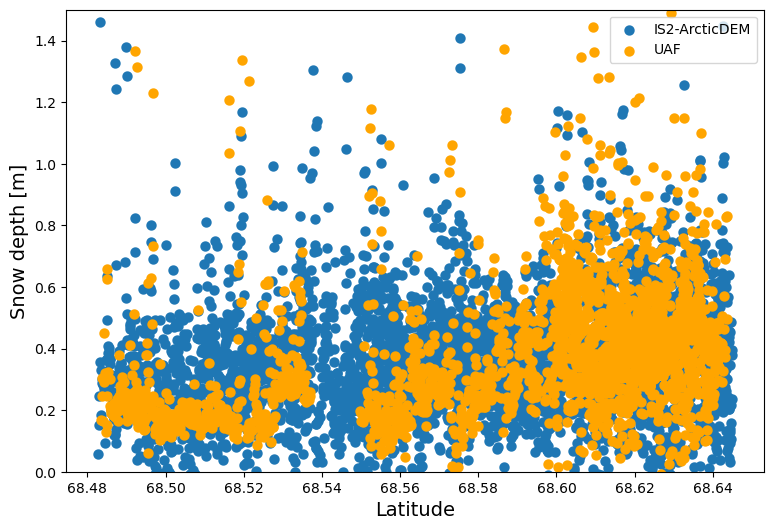

In [35]:
import matplotlib.pyplot as plt

# Line plot of along-track snow depths
fig, ax = plt.subplots(figsize=(9,6))
atl06sr_arc_gdf.plot(kind='scatter', ax=ax, x='lat', y='is2_snow_depth',
                     linewidth=3, label='IS2-ArcticDEM')
atl06sr_uaf_gdf.plot(kind='scatter', ax=ax, x='lat', y='lidar_snow_depth',
                     linewidth=3, color='orange', label='UAF')
ax.set_xlabel('Latitude', fontsize=14)
ax.set_ylabel('Snow depth [m]', fontsize=14)
ax.set_ylim([0, 1.5])
ax.legend()

Although it's not a 1:1 comparison with the airborne lidar results - the ArcticDEM results have much higher spread - the depths obtained with ArcticDEM are reasonable, and are much faster to obtain. Try using other DEMs over other locations to see the results!